# Imports & paths

In [1]:
import os
import sys
from pathlib import Path

# Silence loky physical-core detection warning on Windows without changing notebook logic.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

# Legacy helpers only as fallback.
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

from src.utils.paths import MODEL_OUTPUTS_ROOT as LEGACY_MODEL_OUTPUTS_ROOT, OUTPUTS
from src.utils.constants import (
    FIG_SIZES,
    AP_NAME_MAP,
    AP_COLOR_MAP,
    AP_DASH_MAP,
    AP_LEGEND_ORDER,
)
from src.data.model_metrics import load_meso_results

from cnt_project.visualizations.experiments.paper_figures.ap_curves import (
    plot_ap_curves,
)

_output_root_candidates = [
    Path(LEGACY_MODEL_OUTPUTS_ROOT),
    PROJECT_ROOT / "global_outputs" / "reports" / "edt_comparison",
    PROJECT_ROOT / "Global_Outputs" / "reports" / "edt_comparison",
    PROJECT_ROOT / "global_outputs" / "runs",
]
MODEL_OUTPUTS_ROOT = next(
    (p for p in _output_root_candidates if p.exists()),
    Path(LEGACY_MODEL_OUTPUTS_ROOT),
)
print(f"Using MODEL_OUTPUTS_ROOT: {MODEL_OUTPUTS_ROOT}")

Using MODEL_OUTPUTS_ROOT: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\reports\edt_comparison


# Experiments + styling

In [3]:
# Which models to include
stardist_list = [
    'fluo_centerness',
    'fluo_edt_standard',
    'fluo_new_edt',
    'fluo_edt_LB',
]
detectron2_list = []
wormswin_list = []

model_names = stardist_list + detectron2_list + wormswin_list

# Mappings (short names, colors, dashes, legend order)
name_map = AP_NAME_MAP
color_map = AP_COLOR_MAP
dash_map = AP_DASH_MAP
legend_order = AP_LEGEND_ORDER

save_dir = OUTPUTS['scoring']


# Load & merge meso CSVs 

In [4]:
# Load and merge on IoU_thresh (keeps only rows present across models)
meso_dfs = []
for exp in model_names:
    try:
        df = load_meso_results(MODEL_OUTPUTS_ROOT, exp)  # uses src/data/model_metrics.py
        meso_dfs.append(df)
    except FileNotFoundError as e:
        print(f"[warn] {e}")

if not meso_dfs:
    raise RuntimeError("No ap_results_poly_ALL.csv files found for given models.")

# Outer merge keeps all IoUs; inner merge keeps intersection.
# Your original used outer; we'll match that:
from functools import reduce
meso_results = reduce(lambda l, r: pd.merge(l, r, on='IoU_thresh', how='outer'), meso_dfs)

# Sort by IoU for clean plotting
meso_results = meso_results.sort_values('IoU_thresh').reset_index(drop=True)

ious = meso_results['IoU_thresh'].values


# Build series from CSV columns 

In [5]:
def pick_metric_column(df_columns, exp_name, candidates=('AP', 'precision')):
    """Return the first matching '<exp>_<metric>' column if present."""
    for metric in candidates:
        col = f"{exp_name}_{metric}"
        if col in df_columns:
            return col
    # If nothing matches, try any column that startswith exp_name but isn't IoU
    fallback = [c for c in df_columns if c.startswith(exp_name + "_") and c != 'IoU_thresh']
    return fallback[0] if fallback else None

# Build {label -> y-values} for the chosen metric (AP/precision)
series = {}
for exp in stardist_list:
    col = pick_metric_column(meso_results.columns, exp, candidates=('AP', 'precision'))
    if not col:
        print(f"[warn] No AP/precision column found for {exp}, skipping.")
        continue
    label = name_map.get(exp, exp)
    series[label] = meso_results[col].values

# Re-order the dict by the desired legend order (and plotting order)
ordered_series = {lbl: series[lbl] for lbl in legend_order if lbl in series}


# Plot Figure

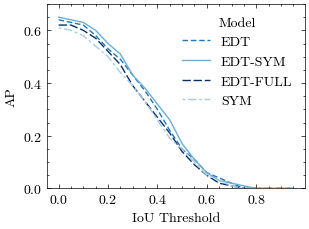

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\scoring\scoring_functions_Ap_ver2.svg


In [6]:
# Ensure output folder exists
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "scoring_functions_Ap_ver2.svg")

plot_ap_curves(
    ious=ious,
    series=ordered_series,
    colors=color_map,
    dashes=dash_map,
    ylim=(0.0, 0.7),
    figsize=FIG_SIZES["double_half"],
    save_path=save_path
)
print(f"Saved: {save_path}")
